### Прогноз цен на авиабилеты

Авиакомпания — это компания, предоставляющая услуги воздушных перевозок пассажиров и грузов. Авиакомпании используют самолеты для предоставления этих услуг и могут заключать партнерские соглашения или альянсы с другими авиакомпаниями в рамках соглашений о код-шеринге, согласно которым они обе предлагают и выполняют один и тот же рейс. Как правило, авиакомпании признаются на основании сертификата или лицензии на осуществление воздушных перевозок, выданной государственным авиационным органом. Авиакомпании могут быть регулярными или чартерными операторами.

Авиакомпании устанавливают цены на свои услуги, стремясь максимизировать прибыль. Ценообразование авиабилетов с годами стало значительно сложнее и в настоящее время в значительной степени определяется компьютеризированными системами управления доходностью.

Цена авиабилета зависит от ряда факторов, таких как продолжительность полета, количество дней до вылета, время прибытия и отправления и т. д. Авиакомпании могут снижать стоимость в моменты, когда им необходимо нарастить спрос, и в моменты, когда билеты менее доступны. Они также могут максимизировать затраты. Цена может зависеть от различных факторов. Каждый фактор имеет свои собственные правила и алгоритмы для установления соответствующей цены. Последние достижения в области искусственного интеллекта (ИИ) и машинного обучения (МО) позволяют выводить такие правила и моделировать изменение цены.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Загрузка данных

In [2]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)

In [3]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Описание набора данных

* **Airline** (Авиакомпания): Название авиакомпании хранится в столбце «Авиакомпания». Это категория, включающая 6 различных авиакомпаний.
* **Flight** (Рейс): Flight хранит информацию о коде рейса самолета. Это категориальный признак.
* **Source City** (Город-источник): Город, из которого вылетает самолет. Это категория, включающая 6 уникальных городов.
* **Departure Time** (Время отправления): это производная категориальная характеристика, полученная путем группировки временных периодов в интервалы. Она хранит информацию о времени отправления и имеет 6 уникальных временных меток.
* **Stops** (Остановки):Категориальный признак с тремя различными значениями, хранящий количество остановок между городами отправления и назначения.
* **Arrival Time** (Время прибытия): это производная категориальная характеристика, созданная путем группировки временных интервалов в интервалы. Она имеет шесть различных временных меток и содержит информацию о времени прибытия.
* **Destination City** (Город назначения): Город, где приземлится самолет. Это категория, включающая 6 уникальных городов.
* **Class** (Класс): Категориальный признак, содержащий информацию о классе места; имеет два различных значения: Бизнес и Эконом.
* **Duration** (Продолжительность): Непрерывный параметр, отображающий общее время, необходимое для поездки между городами в часах.
* **Days Left** (Осталось дней): это производная характеристика, которая рассчитывается путем вычитания даты поездки из даты бронирования.
* **Price** (Цена): Целевая переменная хранит информацию о цене билета.
не билета.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [5]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
df.describe(include='O')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Разведочный анализ данных (РАД, EDA)

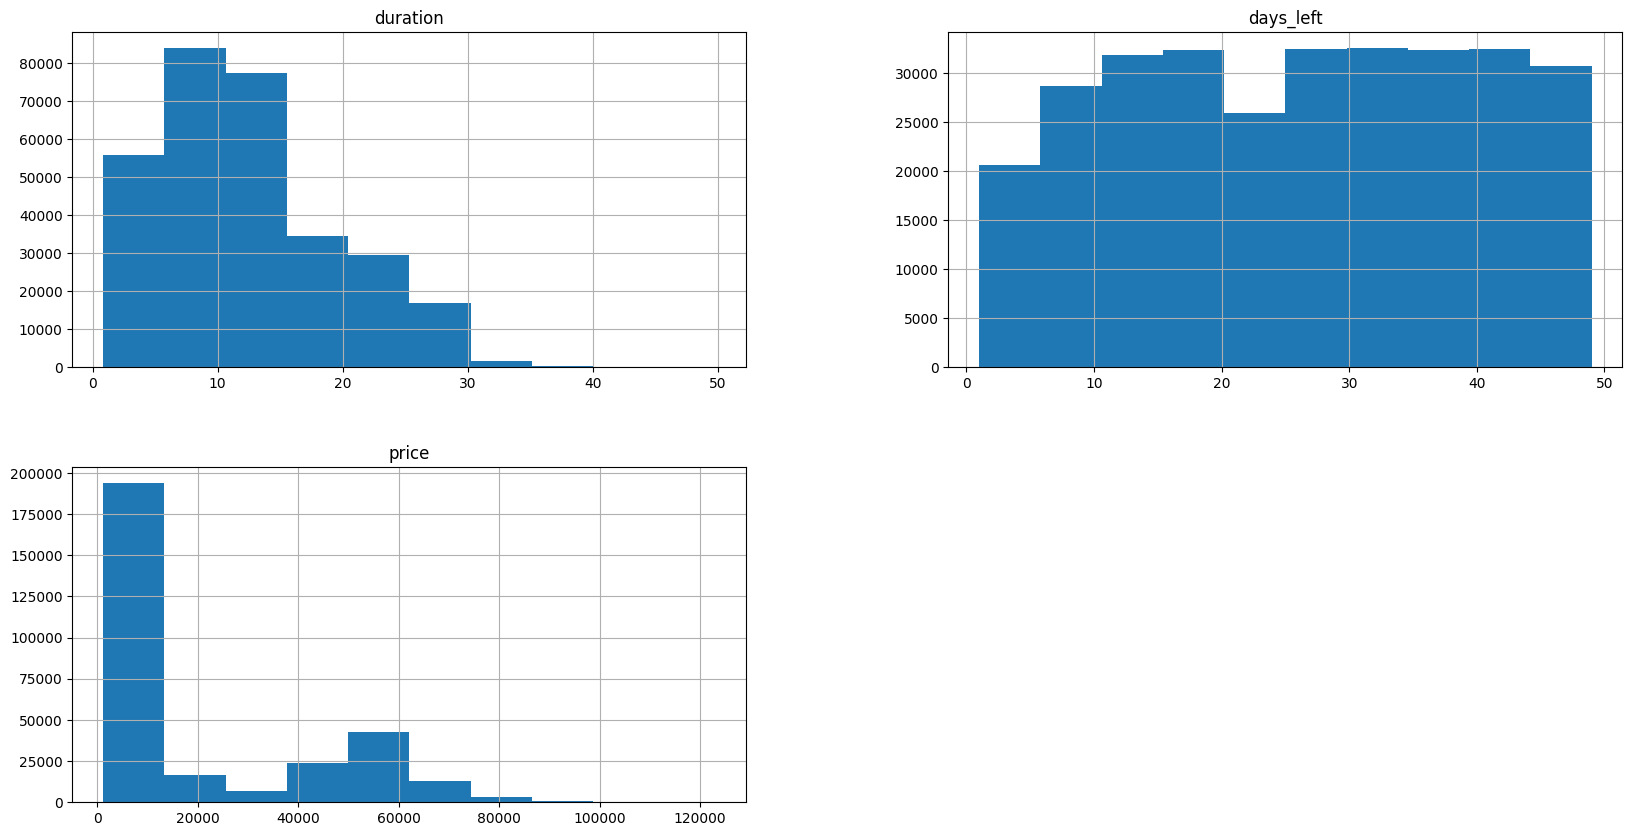

In [7]:
df.hist(figsize=(20,10));

In [8]:
cat_features = [column for column in df.columns if df[column].dtype =="object"]

In [9]:
cat_features

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

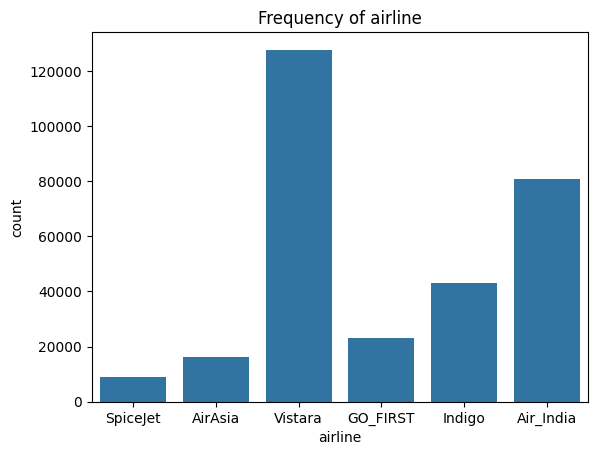

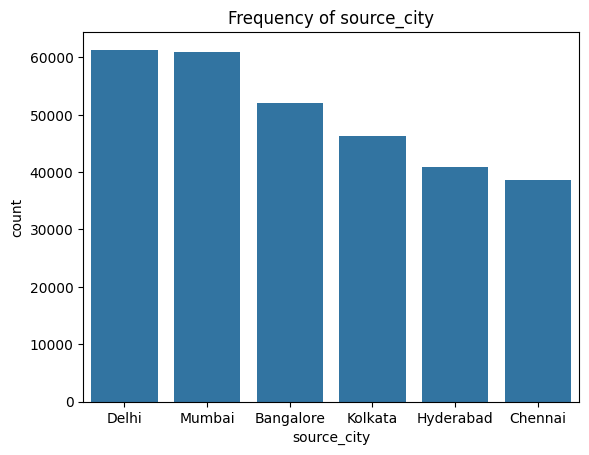

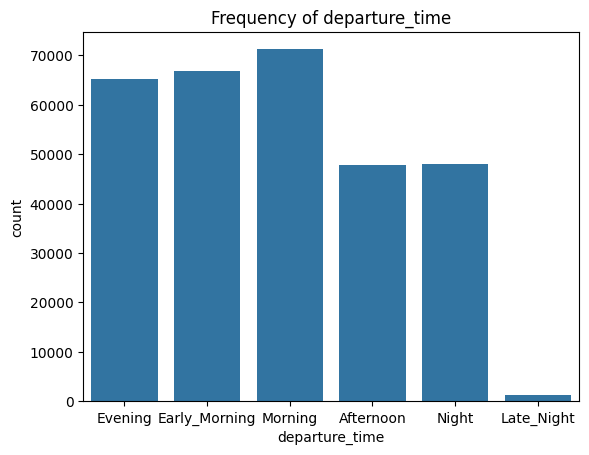

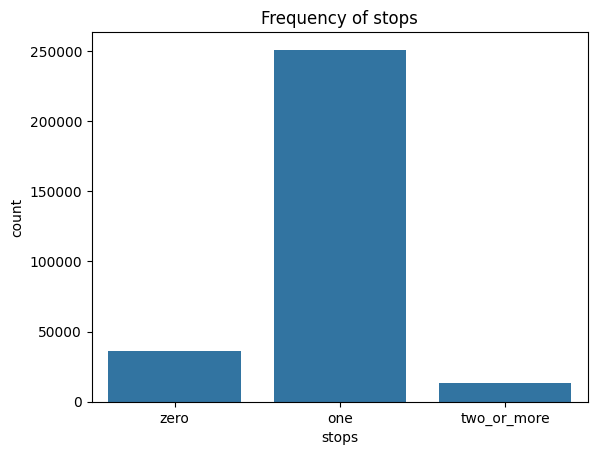

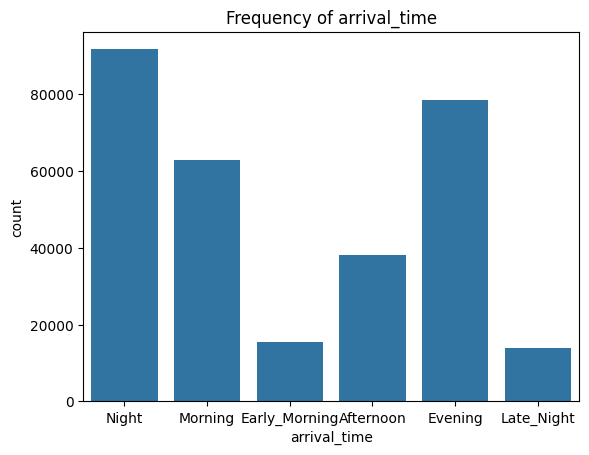

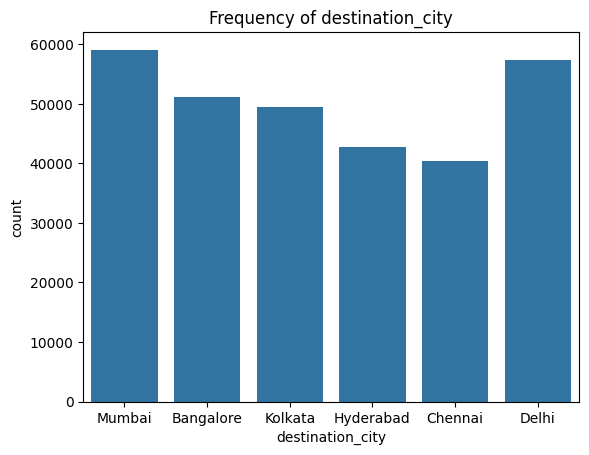

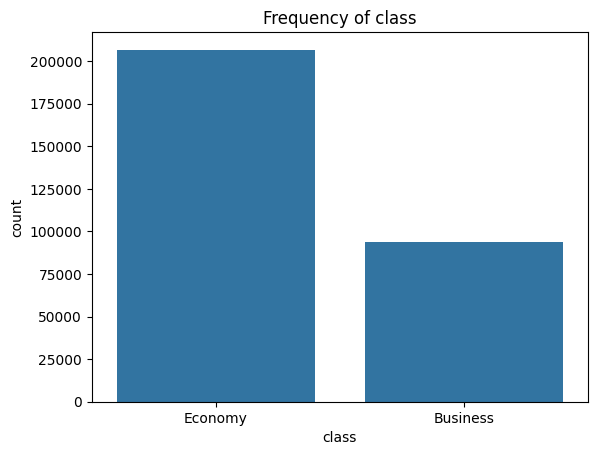

In [10]:
for column in cat_features:
    if column != 'flight':
        sns.countplot(x=df[column], data=df)
        plt.title("Frequency of " + column)
        plt.show()

In [11]:
df[df['flight']=='SG-8709']

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
...,...,...,...,...,...,...,...,...,...,...,...
42049,SpiceJet,SG-8709,Delhi,Evening,one,Early_Morning,Chennai,Economy,13.08,43,4942
42053,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.42,43,4942
42228,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.83,44,4942
42381,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,27.00,45,4942


In [12]:
df[df['flight']=='SG-8709'].head(20)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
919,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,7,5953
1105,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,8,5953
1331,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,9,6060
1493,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,10,6270
1644,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,11,5953


In [13]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

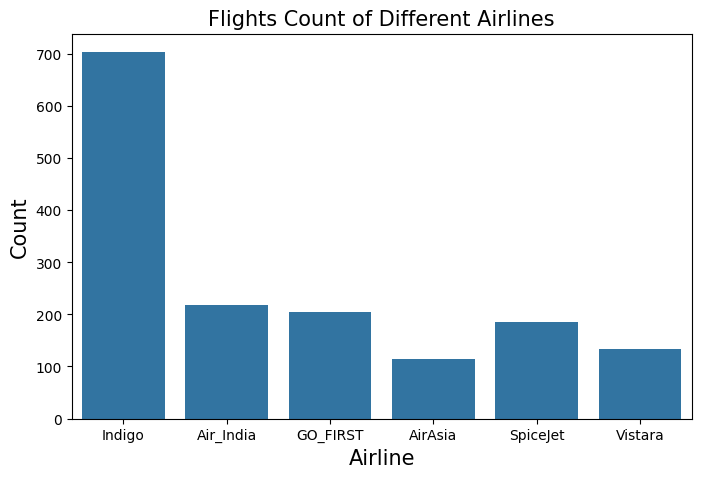

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x=df1['airline'])
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

Индиго одна из самых популярных авиакомпаний.

In [15]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

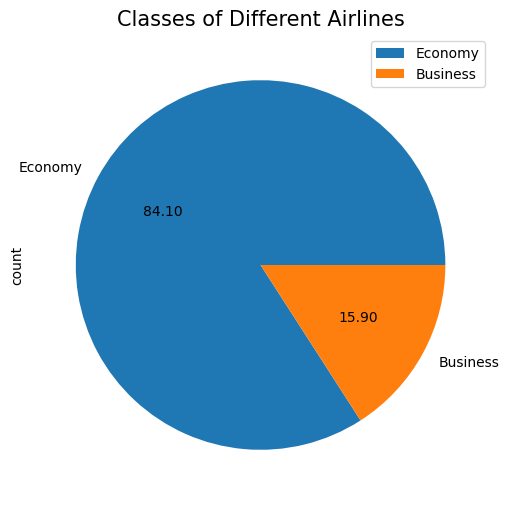

In [16]:
plt.figure(figsize=(8,6))
df2['class'].value_counts().plot(kind='pie',textprops={'color':'black'},autopct='%.2f')
plt.title('Classes of Different Airlines',fontsize=15)
plt.legend(['Economy','Business'])
plt.show()

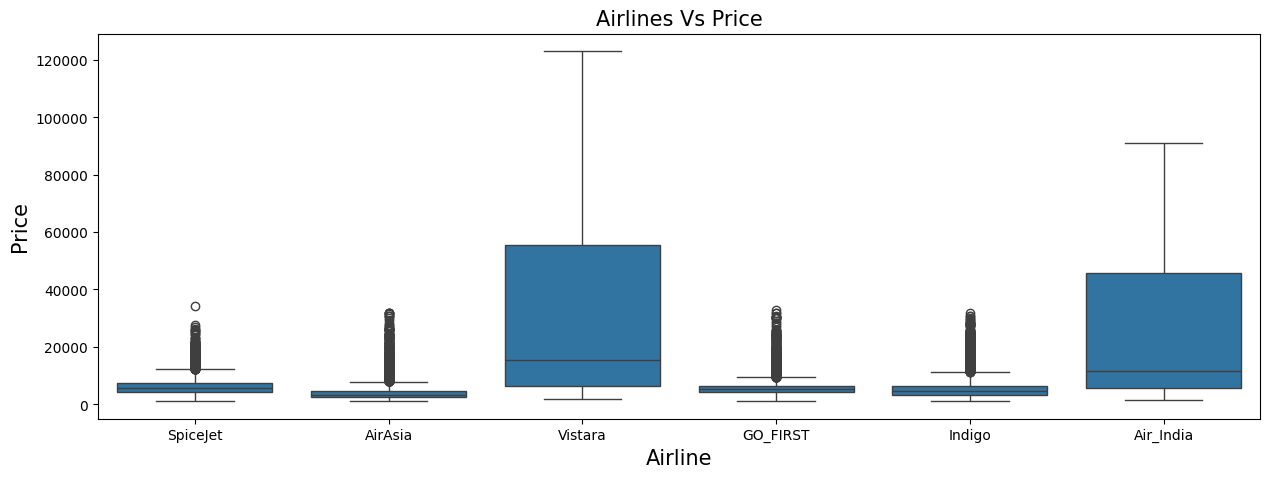

In [17]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['airline'],y=df['price'])
plt.title('Airlines Vs Price',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Авиакомпании Vistara и Air India предлагают самые высокие цены по сравнению с другими. У SpiceJet, AirAsia, GO_First и Indigo цены примерно одинаковые.

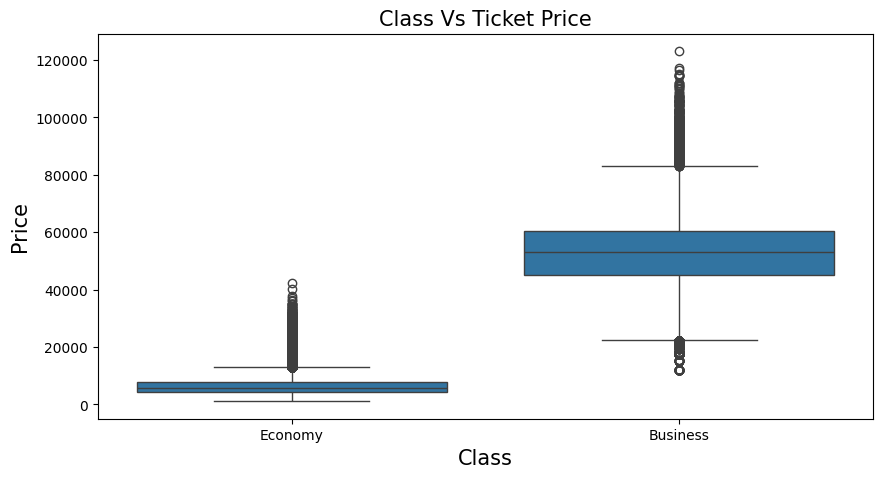

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df)
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билета в бизнес-классе выше, чем в эконом-классе.

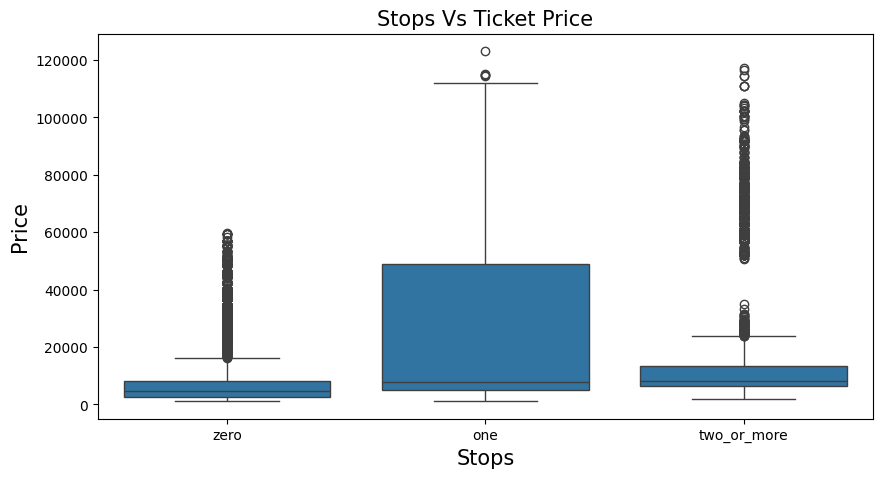

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df)
plt.title('Stops Vs Ticket Price',fontsize=15)
plt.xlabel('Stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

На рейсах с одной пересадкой действует максимальная цена билета.

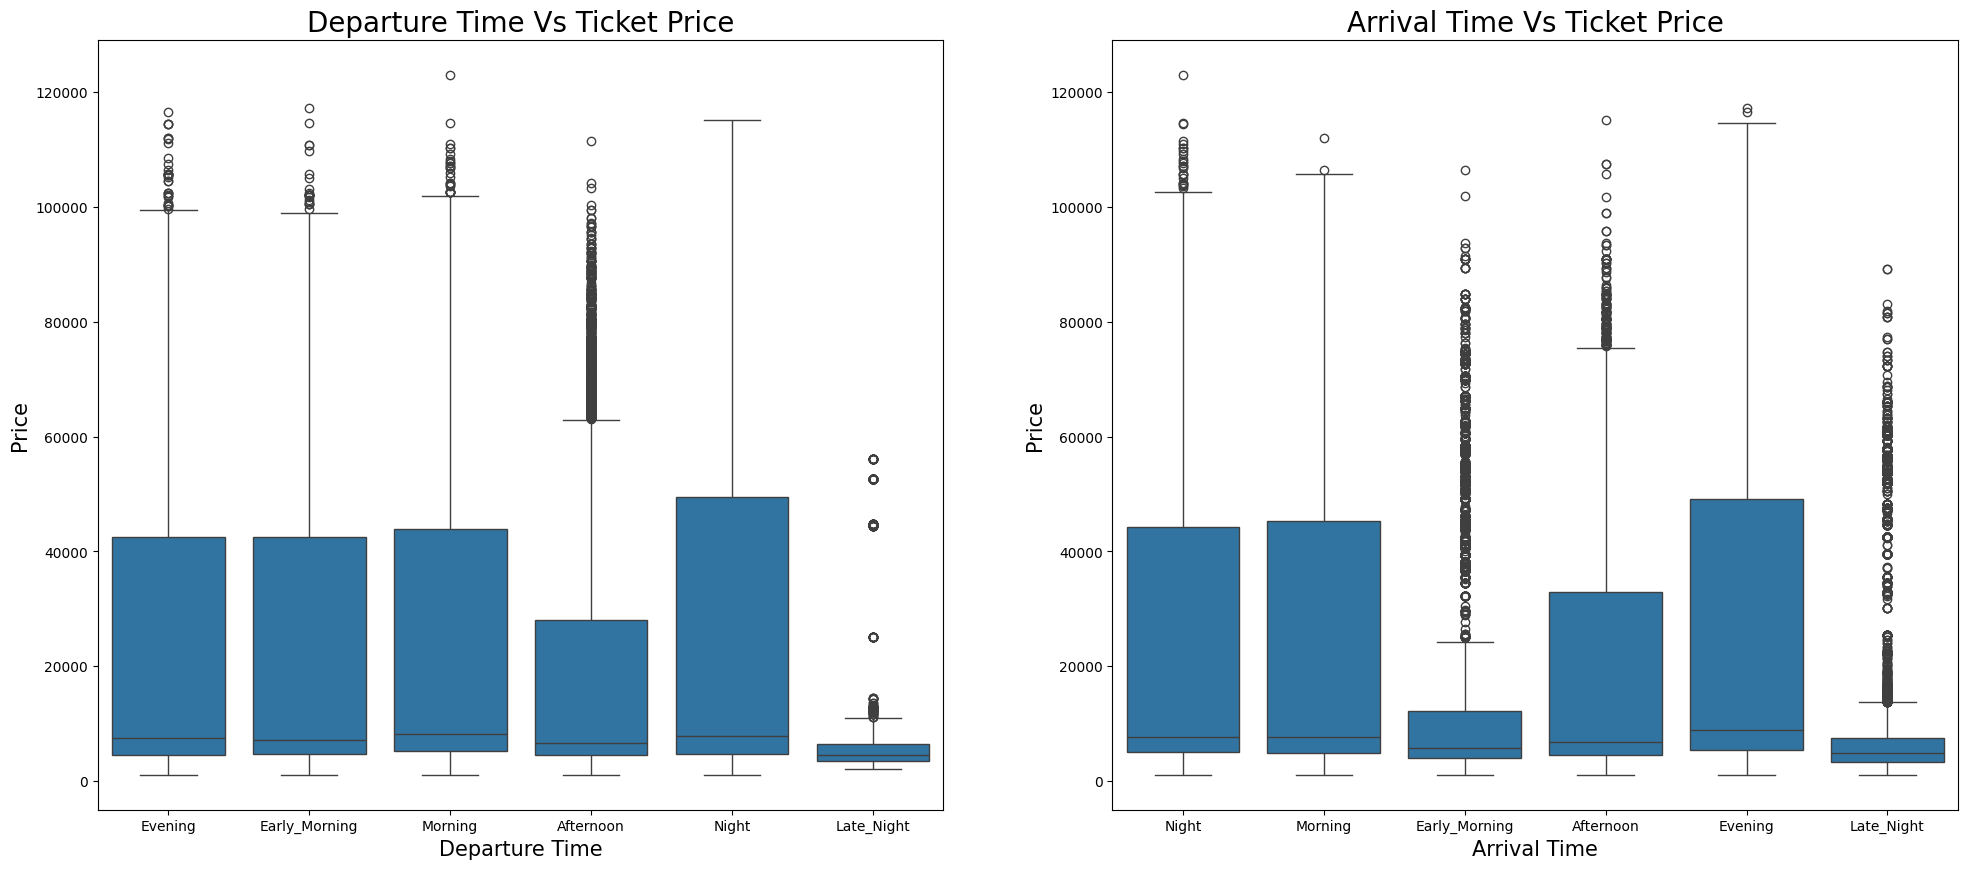

In [20]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='departure_time',y='price',data=df)
plt.title('Departure Time Vs Ticket Price',fontsize=20)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='arrival_time',y='price',data=df)
plt.title('Arrival Time Vs Ticket Price',fontsize=20)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Стоимость билетов на рейсы, вылетающие ночью, выше.
Стоимость билетов практически одинакова для рейсов с вылетом рано утром, утром и вечером.
Низкие цены на билеты на рейсы с поздним ночным вылетом.

Стоимость билетов на рейсы с прибытием вечером выше.
Стоимость билетов практически одинакова для рейсов, прибывающих утром и вечером.
Стоимость билетов низкая на рейсы с поздним ночным временем прибытия, совпадающим со временем отправления.

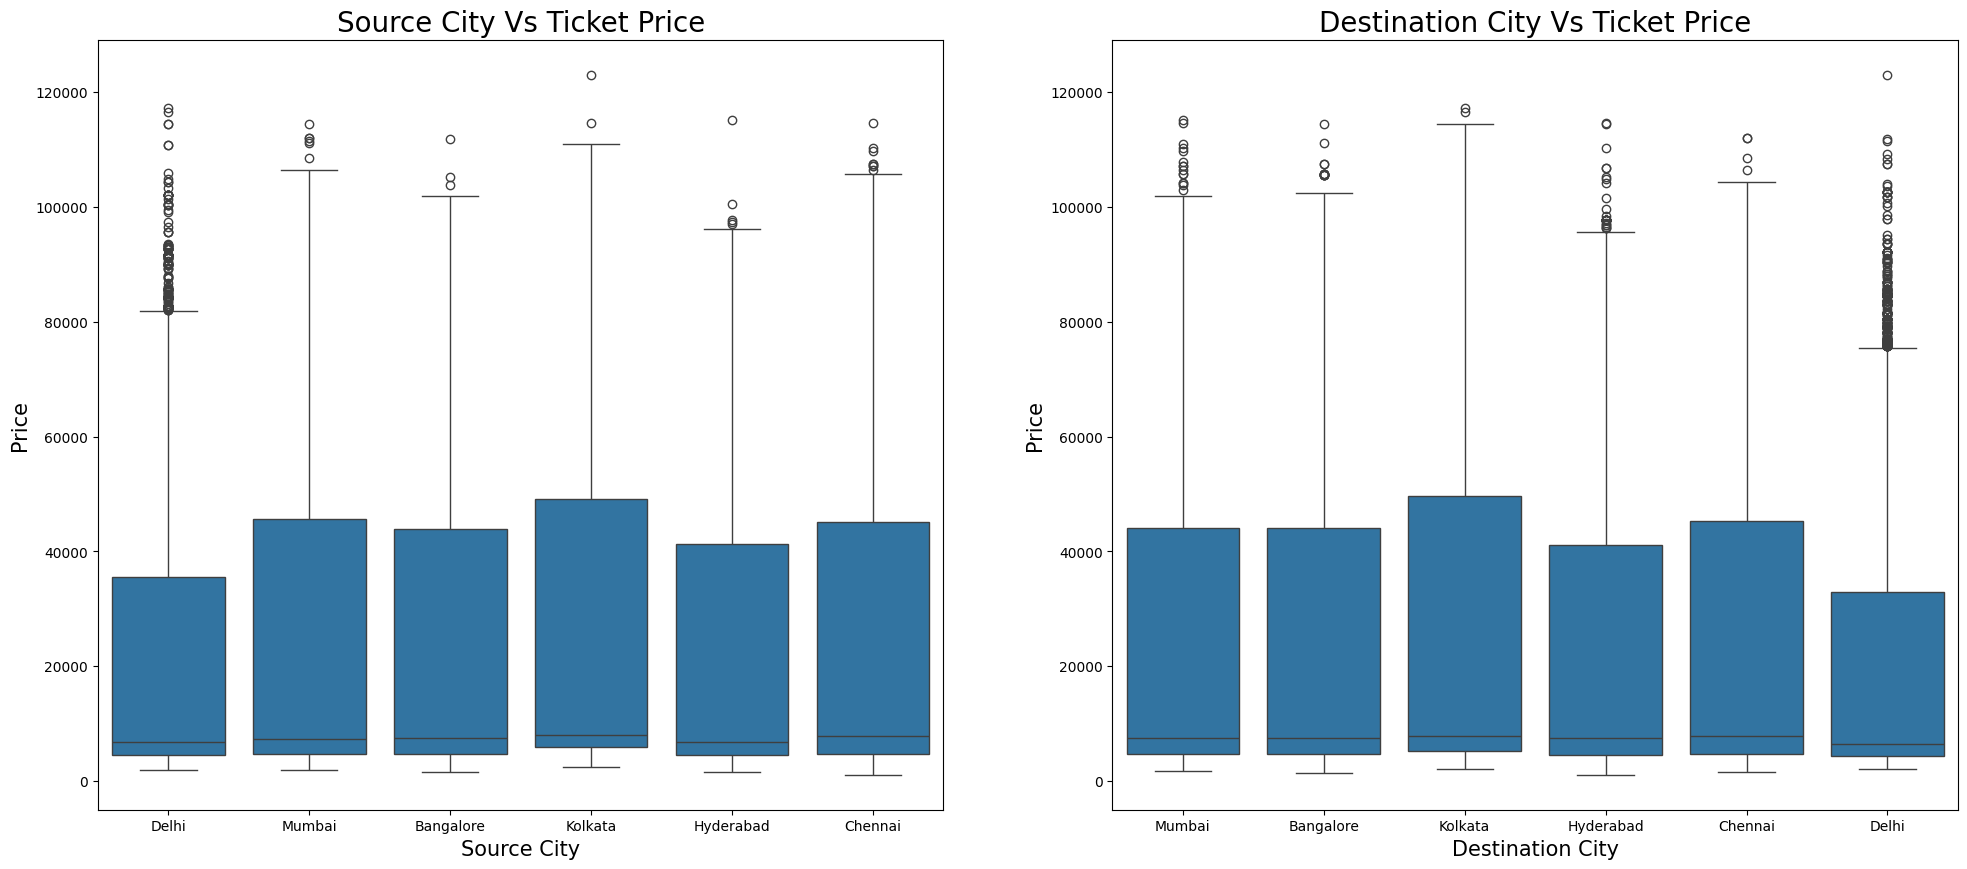

In [21]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='source_city',y='price',data=df)
plt.title('Source City Vs Ticket Price',fontsize=20)
plt.xlabel('Source City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='destination_city',y='price',data=df)
plt.title('Destination City Vs Ticket Price',fontsize=20)
plt.xlabel('Destination City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билетов выше на рейсы, вылетающие из Калькутты.
Стоимость билетов практически одинакова для рейсов из таких городов, как Мумбаи и Ченнаи, Хайдарабад и Бангалор.
Цены на билеты на рейсы из Дели низкие.

Стоимость билетов выше на рейсы, пункты назначения которых — Калькутта и Ченнай.
Стоимость билетов на рейсы в такие города, как Мумбай и Бангалор, практически одинакова.
Цены на билеты на рейсы с городом назначения, таким как Дели, низкие.

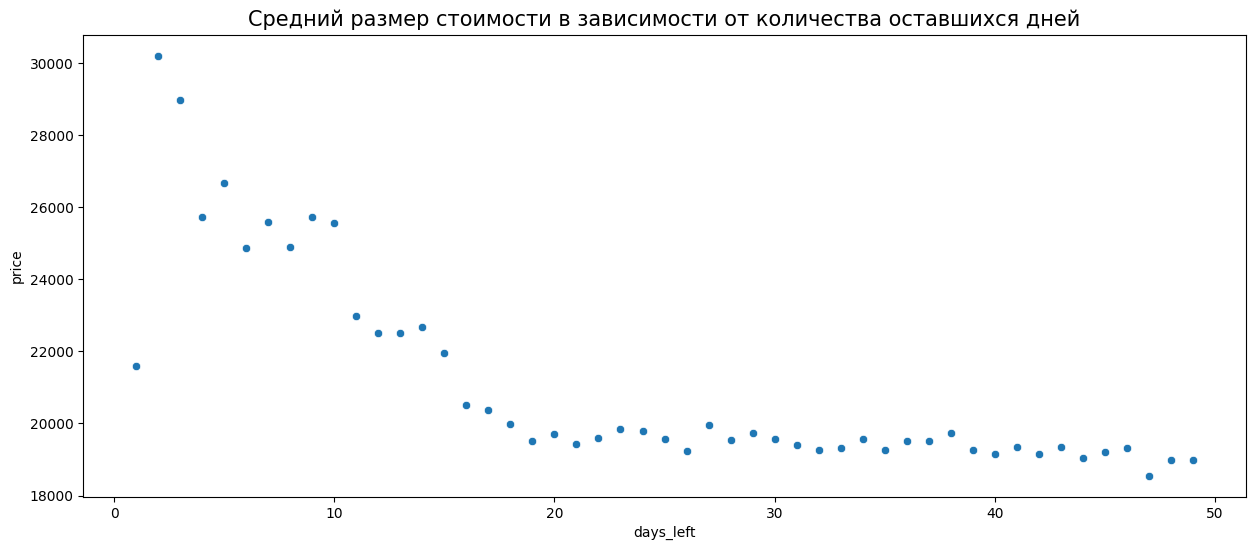

In [22]:
df_temp = df.groupby(['days_left'])['price'].mean().reset_index()

plt.figure(figsize=(15,6))
ax = sns.scatterplot(x="days_left", y="price", data=df_temp).set_title("Средний размер стоимости в зависимости от количества оставшихся дней",fontsize=15)

# Начало работы
## Кодирование данных

In [23]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Способ 1: Label Encoding (для порядковых признаков)
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
df['stops_encoded'] = le.fit_transform(df['stops'])

# Способ 2: One-Hot Encoding (для номинальных признаков)
df = pd.get_dummies(df, columns=['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time'], drop_first=True)

# Способ 3: Target Encoding (среднее значение целевой переменной по категориям)
# Полезно для признака 'flight' с большим числом уникальных значений
flight_target_mean = df.groupby('flight')['price'].mean()
df['flight_encoded'] = df['flight'].map(flight_target_mean)

# Удалить исходные категориальные столбцы если они больше не нужны
df = df.drop(columns=['class', 'stops', 'flight'])

# Проверить результат
df.head()

,duration,days_left,price,class_encoded,stops_encoded,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,flight_encoded
0,2.17,1,5953,1,2,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,4740.022556
1,2.33,1,5953,1,2,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,5072.175573
2,2.17,1,5956,1,2,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,3902.387755
3,2.25,1,5955,1,2,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,31270.540039
4,2.33,1,5955,1,2,False,False,False,False,True,...,False,False,True,False,False,False,False,True,False,33805.822695


## Вывод тепловой карты


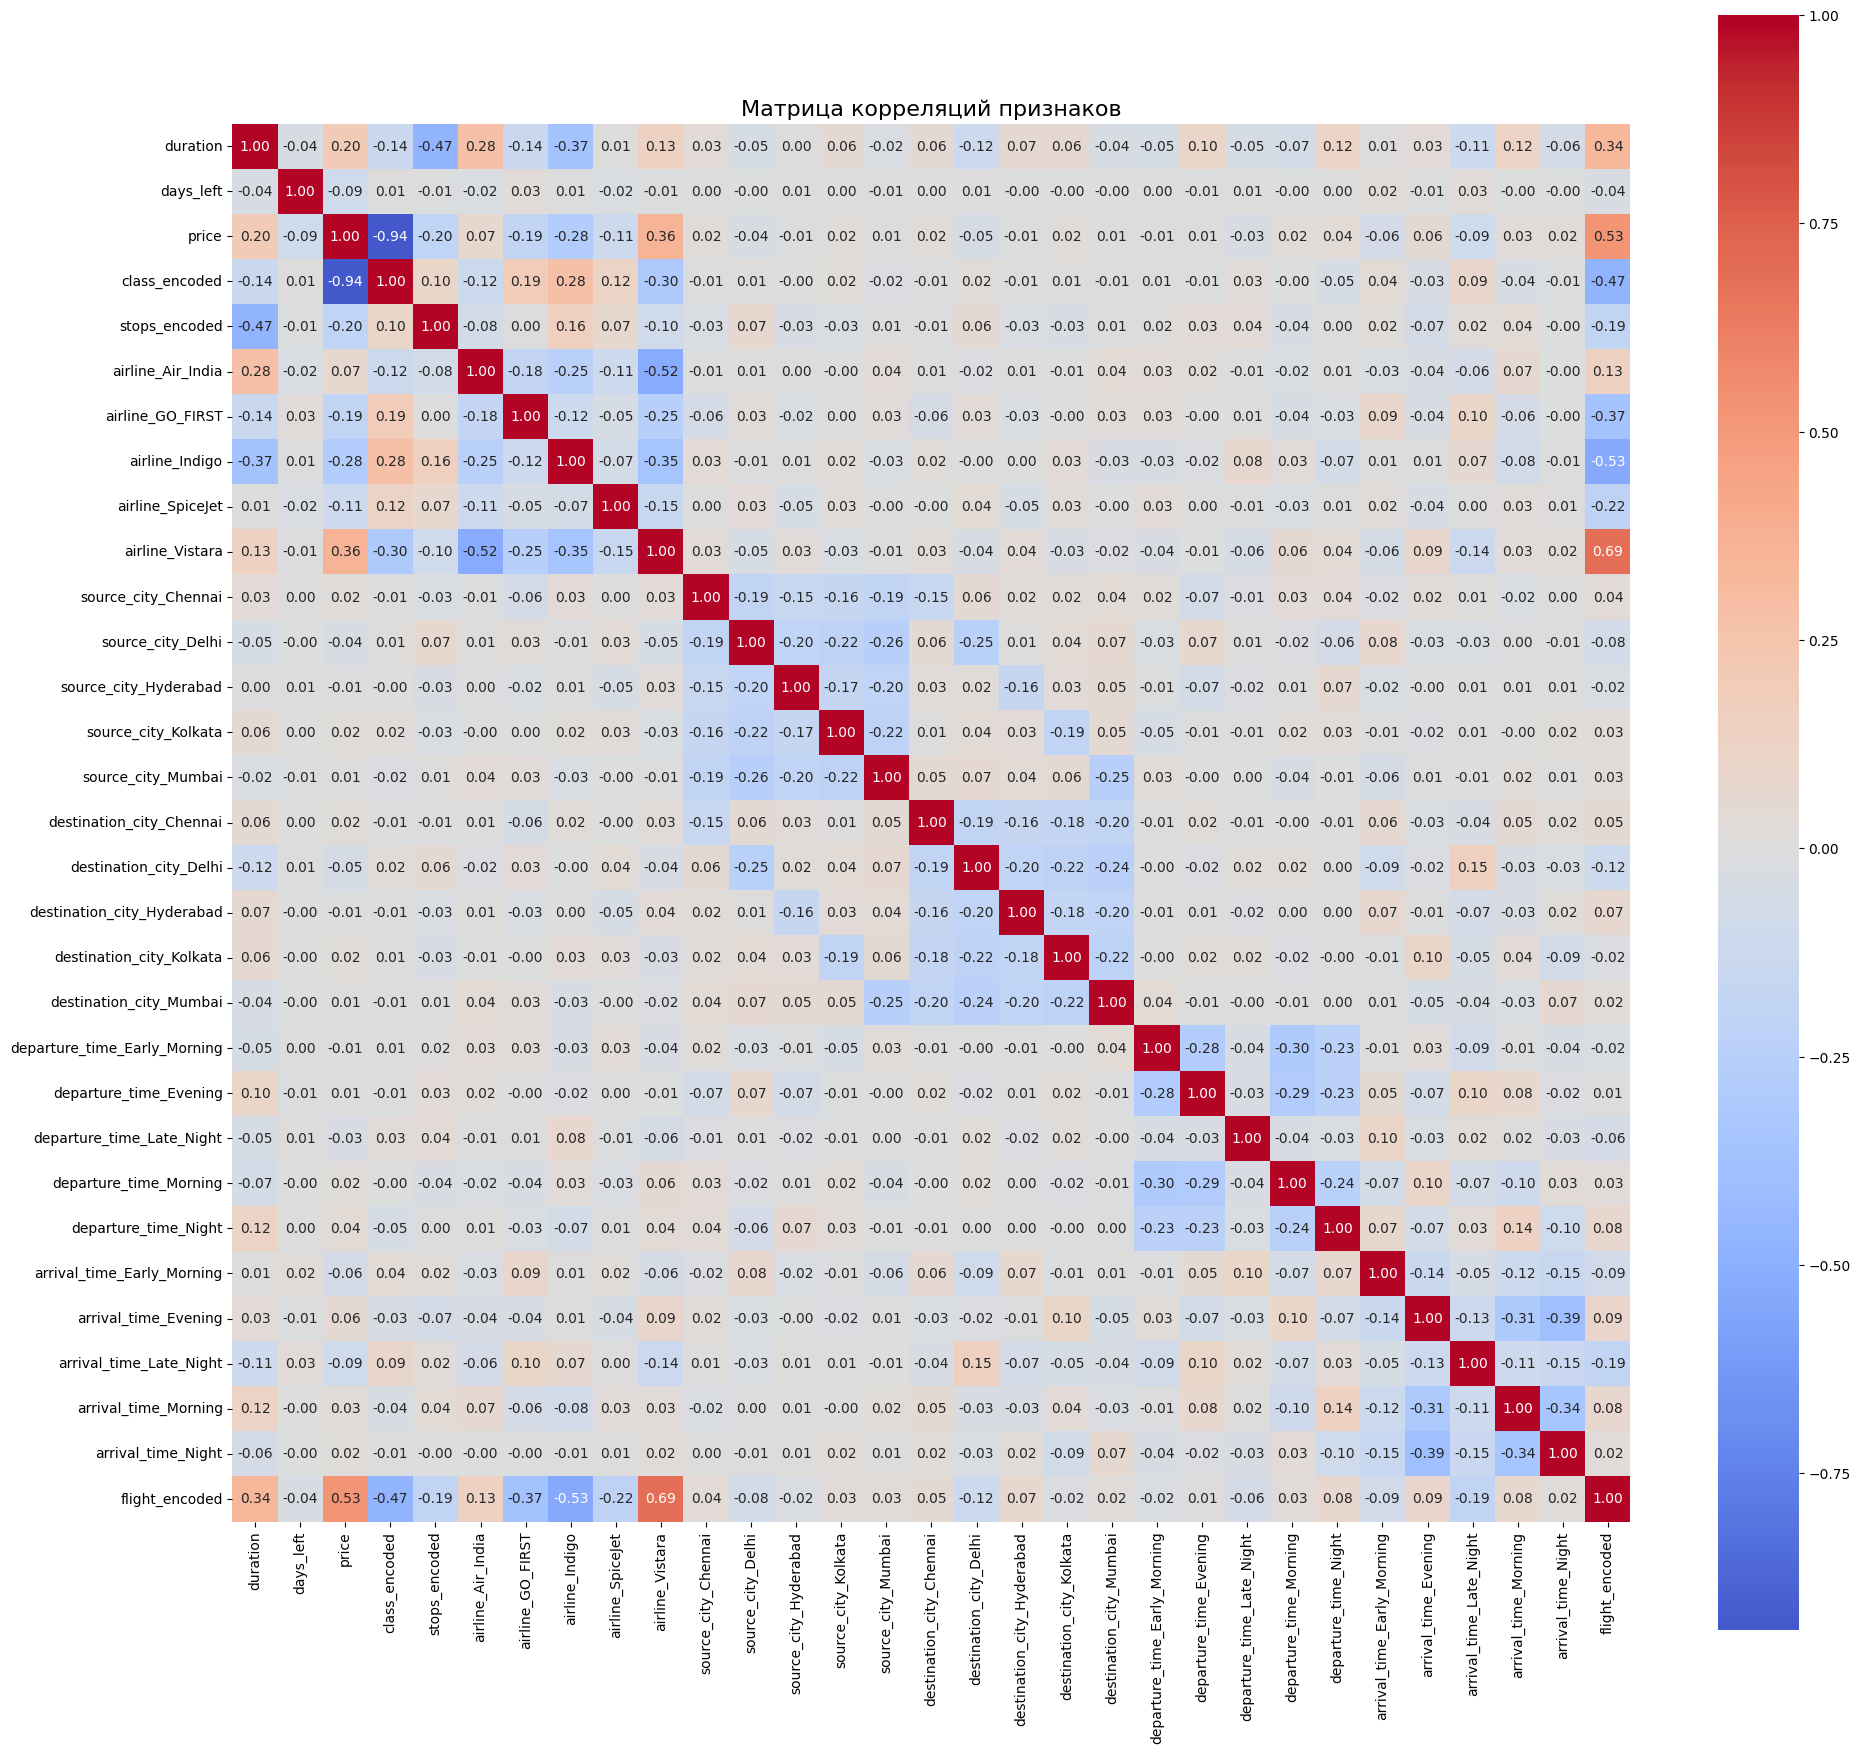

In [24]:
# Тепловая карта корреляций
plt.figure(figsize=(20, 18))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

## Обучение моделей
### Отличие и особенности моделей

#### 1. **Linear Regression (Линейная регрессия)**
- **Суть**: Ищет линейную зависимость между признаками и целевой переменной
- **Формула**: y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ
- **Преимущества**:
  - Быстрое обучение и предсказание
  - Простота интерпретации коэффициентов
  - Работает хорошо для линейных зависимостей
- **Недостатки**:
  - Плохо справляется с нелинейными зависимостями
  - Может предсказывать отрицательные значения (для цены это проблема)
  - Чувствительна к выбросам в данных
- **Когда использовать**: Когда связь между признаками и целевой переменной примерно линейная

#### 2. **Random Forest (Случайный лес)**
- **Суть**: Ансамбль (набор) множества деревьев решений, каждое строится на случайном подмножестве данных
- **Как работает**:
  1. Создает N деревьев решений
  2. Каждое дерево обучается на случайной выборке данных
  3. Финальный результат — среднее значение предсказаний всех деревьев
- **Преимущества**:
  - Отлично захватывает нелинейные зависимости
  - Устойчив к выбросам
  - Показывает важность признаков
  - Параллельное обучение (быстро)
- **Недостатки**:
  - Сложнее интерпретировать, чем Linear Regression
  - Требует больше памяти
  - Может переобучаться на шумных данных
- **Когда использовать**: Когда нужна высокая точность и есть сложные нелинейные зависимости

#### 3. **Gradient Boosting (Градиентный бустинг)**
- **Суть**: Последовательное построение деревьев, где каждое новое дерево исправляет ошибки предыдущих
- **Как работает**:
  1. Строит первое дерево
  2. Вычисляет ошибки предсказания
  3. Строит новое дерево, которое предсказывает эти ошибки
  4. Повторяет процесс N раз
- **Преимущества**:
  - Очень высокая точность предсказаний
  - Хорошо работает с разными типами данных
  - Показывает важность признаков
  - Часто выигрывает на соревнованиях (kaggle)
- **Недостатки**:
  - Медленнее обучается, чем Random Forest
  - Требует тонкой настройки параметров
  - Склонен к переобучению без правильной регуляризации
- **Когда использовать**: Когда нужна максимальная точность и есть время на обучение

Модель 1: Linear Regression
R² Score: 0.9125
MAE: 4561.61
RMSE: 6717.82

Модель 2: Random Forest Regressor
R² Score: 0.9900
MAE: 856.73
RMSE: 2270.83

Модель 3: Gradient Boosting Regressor
R² Score: 0.9656
MAE: 2464.72
RMSE: 4212.31

Сравнение моделей
              Модель  R² Score          MAE         RMSE
0  Linear Regression  0.912453  4561.607480  6717.822967
1      Random Forest  0.989996   856.727191  2270.828943
2  Gradient Boosting  0.965579  2464.722845  4212.313288


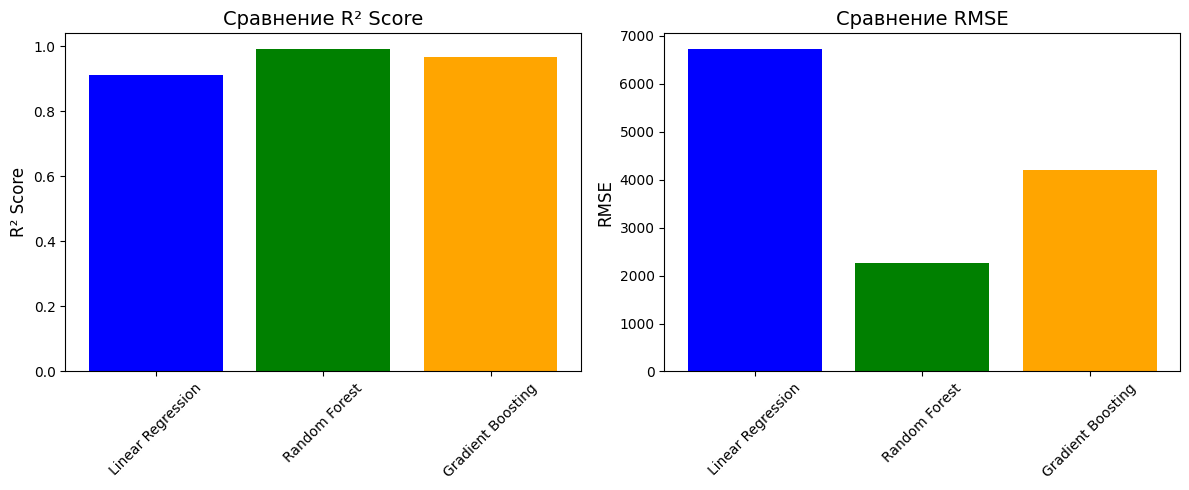

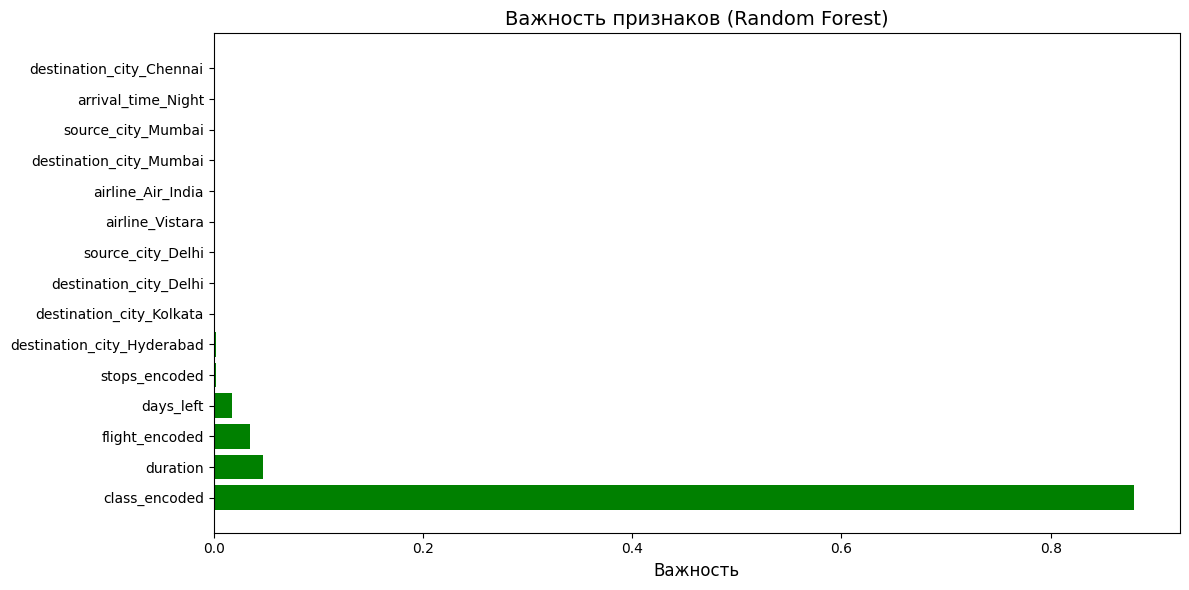

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Подготовка данных
X = df.drop('price', axis=1)  # Признаки
y = df['price']  # Целевая переменная

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Модель 1: Linear Regression
print("=" * 50)
print("Модель 1: Linear Regression")
print("=" * 50)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"R² Score: {lr_r2:.4f}")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}\n")

# Модель 2: Random Forest Regressor
print("=" * 50)
print("Модель 2: Random Forest Regressor")
print("=" * 50)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"R² Score: {rf_r2:.4f}")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}\n")

# Модель 3: Gradient Boosting Regressor
print("=" * 50)
print("Модель 3: Gradient Boosting Regressor")
print("=" * 50)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"R² Score: {gb_r2:.4f}")
print(f"MAE: {gb_mae:.2f}")
print(f"RMSE: {gb_rmse:.2f}\n")

# Сравнение моделей
print("=" * 50)
print("Сравнение моделей")
print("=" * 50)
models_comparison = pd.DataFrame({
    'Модель': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [lr_r2, rf_r2, gb_r2],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
})
print(models_comparison)

# Визуализация сравнения моделей
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(models_comparison['Модель'], models_comparison['R² Score'], color=['blue', 'green', 'orange'])
plt.title('Сравнение R² Score', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(models_comparison['Модель'], models_comparison['RMSE'], color=['blue', 'green', 'orange'])
plt.title('Сравнение RMSE', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Важность признаков для Random Forest
plt.figure(figsize=(12, 6))
feature_importance_rf = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf_model.feature_importances_
}).sort_values('Важность', ascending=False).head(15)

plt.barh(feature_importance_rf['Признак'], feature_importance_rf['Важность'], color='green')
plt.title('Важность признаков (Random Forest)', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.tight_layout()
plt.show()

## **Вывод результатов моделей** (более развернутый формат)


РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ

Первые 10 предсказаний:
   Фактическая цена  Linear Regression  Random Forest  Gradient Boosting
0              7366        5377.038581        7369.84        6124.369971
1             64831       55044.547479       70521.05       62941.875899
2              6195       12138.843294        6195.00        7553.502052
3             60160       54007.963809       60319.04       54206.690993
4              6578        8667.348999        6572.54        6818.654919
5              4555        9963.734752        6371.53        8562.762993
6             23838       47636.245686       24322.28       25323.880833
7              3860        5411.367154        3860.00        3503.196617
8             32230       47784.825483       37072.67       41119.417569
9             76841       57856.404469       66109.24       64397.033457

АНАЛИЗ ОШИБОК МОДЕЛЕЙ
                        Linear Regression  Random Forest  Gradient Boosting
Средняя ошибка              

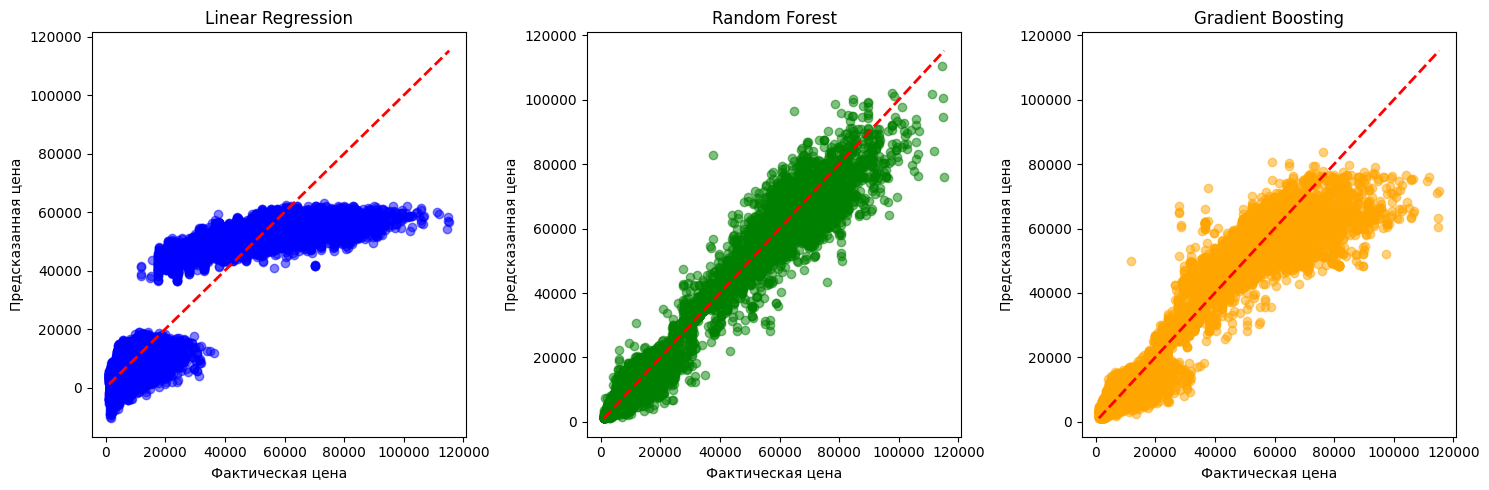

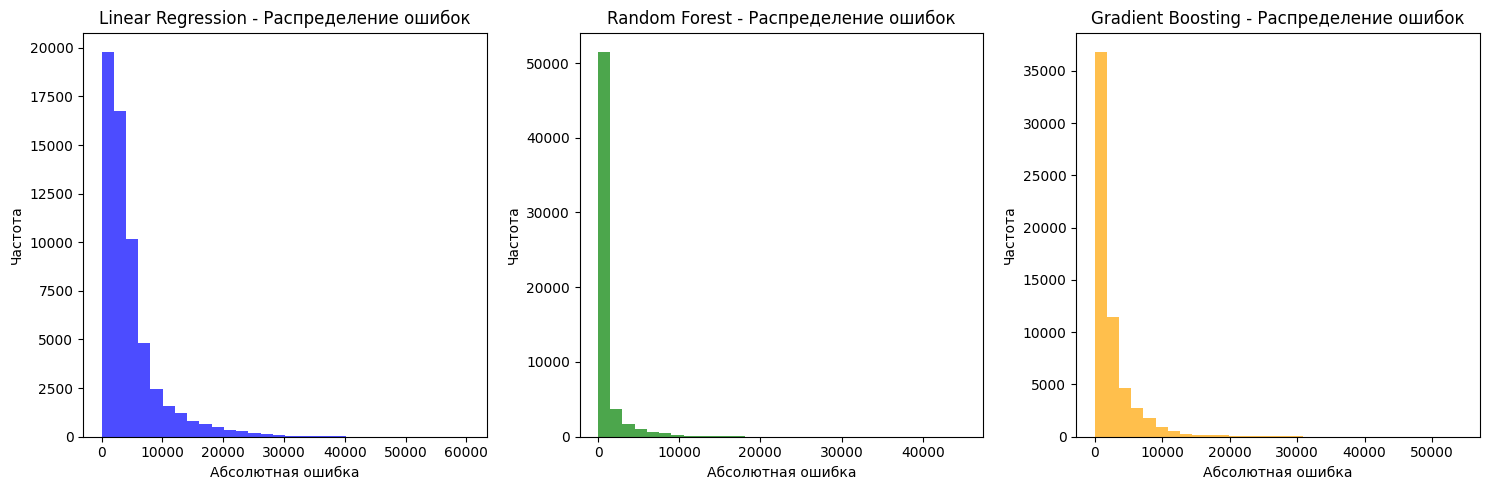


ЛУЧШАЯ МОДЕЛЬ
По R² Score: Random Forest (R² = 0.9900)
По RMSE: Random Forest (RMSE = 2270.83)


In [26]:
# Вывод результатов предсказаний
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)

# Создание DataFrame с результатами
results_df = pd.DataFrame({
    'Фактическая цена': y_test.values,
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
})

print("\nПервые 10 предсказаний:")
print(results_df.head(10))

# Расчет ошибок для каждого предсказания
print("\n" + "=" * 50)
print("АНАЛИЗ ОШИБОК МОДЕЛЕЙ")
print("=" * 50)

lr_errors = np.abs(y_test.values - lr_pred)
rf_errors = np.abs(y_test.values - rf_pred)
gb_errors = np.abs(y_test.values - gb_pred)

errors_df = pd.DataFrame({
    'Linear Regression': [lr_errors.mean(), lr_errors.std(), lr_errors.min(), lr_errors.max()],
    'Random Forest': [rf_errors.mean(), rf_errors.std(), rf_errors.min(), rf_errors.max()],
    'Gradient Boosting': [gb_errors.mean(), gb_errors.std(), gb_errors.min(), gb_errors.max()]
}, index=['Средняя ошибка', 'Стандартное отклонение', 'Минимальная ошибка', 'Максимальная ошибка'])

print(errors_df)

# Визуализация фактических vs предсказанных значений
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, lr_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression', fontsize=12)
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')

plt.subplot(1, 3, 2)
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest', fontsize=12)
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')

plt.subplot(1, 3, 3)
plt.scatter(y_test, gb_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Gradient Boosting', fontsize=12)
plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')

plt.tight_layout()
plt.show()

# Распределение ошибок
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(lr_errors, bins=30, color='blue', alpha=0.7)
plt.title('Linear Regression - Распределение ошибок', fontsize=12)
plt.xlabel('Абсолютная ошибка')
plt.ylabel('Частота')

plt.subplot(1, 3, 2)
plt.hist(rf_errors, bins=30, color='green', alpha=0.7)
plt.title('Random Forest - Распределение ошибок', fontsize=12)
plt.xlabel('Абсолютная ошибка')
plt.ylabel('Частота')

plt.subplot(1, 3, 3)
plt.hist(gb_errors, bins=30, color='orange', alpha=0.7)
plt.title('Gradient Boosting - Распределение ошибок', fontsize=12)
plt.xlabel('Абсолютная ошибка')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ЛУЧШАЯ МОДЕЛЬ")
print("=" * 50)
best_model_r2 = models_comparison.loc[models_comparison['R² Score'].idxmax()]
print(f"По R² Score: {best_model_r2['Модель']} (R² = {best_model_r2['R² Score']:.4f})")

best_model_rmse = models_comparison.loc[models_comparison['RMSE'].idxmin()]
print(f"По RMSE: {best_model_rmse['Модель']} (RMSE = {best_model_rmse['RMSE']:.2f})")

## Выводы по результатам

Протестировал три модели и выяснили, что **Random Forest** работает лучше всех:
- Угадывает цену с точностью 99% (R² = 0.99)
- Ошибается в среднем на 857 рублей
- Предсказания близки к реальным ценам

**Gradient Boosting** тоже неплохо справляется (R² = 0.97), но немного хуже Random Forest.

**Linear Regression** — самая слабая из трех. Часто ошибается на большие суммы и иногда предсказывает отрицательные цены, чего не может быть в реальности.

**Какие факторы влияют на цену?**

Random Forest показала, что на цену билета влияют:
1. **Класс билета** (Business или Economy) — это главный фактор
2. **Продолжительность полета** — чем дольше летим, тем дороже
3. **Номер рейса** — разные авиакомпании разные цены устанавливают
4. **Количество дней до вылета** — обычно ближе к дате вылета, дороже билет

**Итоговая рекомендация:**

Для прогнозирования цен на авиабилеты используйте **Random Forest** — она дает самые точные и надежные предсказания.